# 🫀 Предсказание болезни сердца — UCI Heart Disease Dataset

**Цель исследования:** построить модели машинного обучения для предсказания наличия сердечно-сосудистого заболевания на основе клинических показателей пациента.

**Датасет:** UCI Heart Disease Dataset (адаптированная версия)  
**Задача:** Бинарная классификация (0 — нет болезни, 1 — есть болезнь)

---

## Описание признаков

| Признак | Описание |
|---------|----------|
| `age` | Возраст пациента |
| `sex` | Пол (1 = мужчина, 0 = женщина) |
| `cp` | Тип боли в груди (0–3) |
| `trestbps` | Артериальное давление в покое (мм рт. ст.) |
| `chol` | Холестерин (мг/дл) |
| `fbs` | Сахар в крови натощак > 120 мг/дл (1 = да) |
| `restecg` | Результаты ЭКГ в покое (0–2) |
| `thalach` | Максимальная ЧСС |
| `exang` | Стенокардия при нагрузке (1 = да) |
| `oldpeak` | Депрессия ST при нагрузке |
| `slope` | Наклон пика ST (0–2) |
| `ca` | Число крупных сосудов (0–4) |
| `thal` | Талассемия (0–3) |
| `target` | **Целевая переменная** (1 = болезнь, 0 = норма) |

## 1. Импорт библиотек

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)

# Алгоритмы
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

print('Все библиотеки успешно импортированы ✅')

Все библиотеки успешно импортированы ✅


## 2. Загрузка и первичный осмотр данных

In [18]:
df = pd.read_csv('heart_disease.csv')
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head(10)

Размер датасета: 101 строк, 14 столбцов


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


In [19]:
print('=== Типы данных и пропуски ===')
print(df.info())

=== Типы данных и пропуски ===
<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       101 non-null    int64  
 1   sex       101 non-null    int64  
 2   cp        101 non-null    int64  
 3   trestbps  101 non-null    int64  
 4   chol      101 non-null    int64  
 5   fbs       101 non-null    int64  
 6   restecg   101 non-null    int64  
 7   thalach   101 non-null    int64  
 8   exang     101 non-null    int64  
 9   oldpeak   101 non-null    float64
 10  slope     101 non-null    int64  
 11  ca        101 non-null    int64  
 12  thal      101 non-null    int64  
 13  target    101 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 11.2 KB
None


In [20]:
print('=== Основная статистика ===')
df.describe().round(2)

=== Основная статистика ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00
mean,55.50,0.69,0.83,133.85,243.93,0.19,0.55,146.23,0.32,1.20,1.40,0.81,3.35,0.38
std,9.21,0.46,1.07,16.15,54.33,0.39,0.52,23.10,0.47,1.14,0.68,1.06,2.11,0.49
min,35.00,0.00,0.00,100.00,131.00,0.00,0.00,88.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,123.00,206.00,0.00,0.00,130.00,0.00,0.40,1.00,0.00,2.00,0.00
50%,57.00,1.00,0.00,130.00,236.00,0.00,1.00,150.00,0.00,1.00,2.00,0.00,2.00,0.00
75%,63.00,1.00,2.00,140.00,270.00,0.00,1.00,163.00,1.00,1.60,2.00,2.00,3.00,1.00
max,74.00,1.00,3.00,200.00,417.00,1.00,2.00,188.00,1.00,5.60,2.00,4.00,7.00,1.00


In [21]:
print('=== Пропущенные значения ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'Пропущенных значений нет ✅')

=== Пропущенные значения ===
Пропущенных значений нет ✅


## 3. Разведочный анализ данных (EDA)

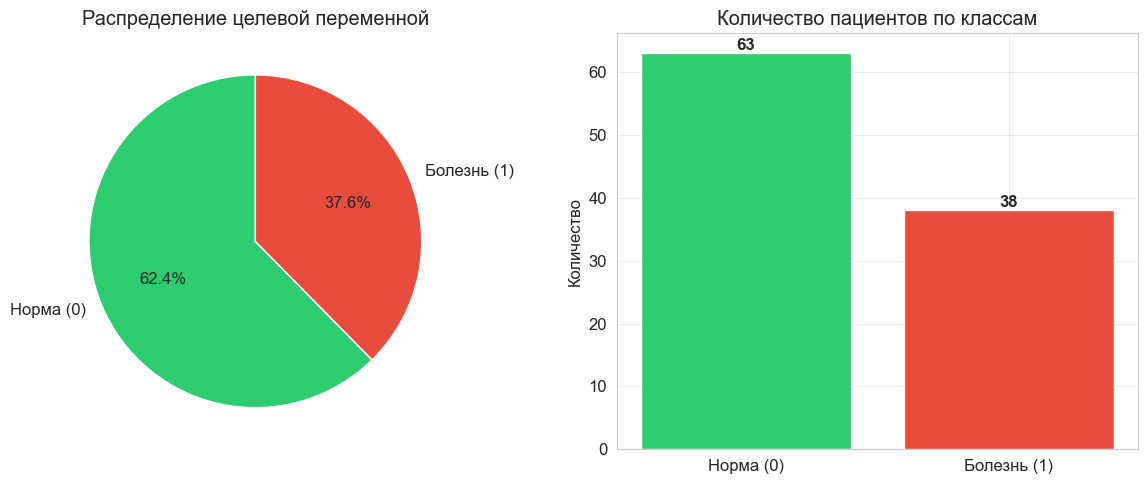


Класс 0 (норма): 63 (62.4%)
Класс 1 (болезнь): 38 (37.6%)


In [22]:
# Распределение целевой переменной
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['target'].value_counts()
labels = ['Норма (0)', 'Болезнь (1)']

axes[0].pie(counts, labels=labels, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0].set_title('Распределение целевой переменной')

axes[1].bar(labels, counts, color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Количество пациентов по классам')
axes[1].set_ylabel('Количество')
for i, v in enumerate(counts):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nКласс 0 (норма): {counts[0]} ({counts[0]/len(df)*100:.1f}%)')
print(f'Класс 1 (болезнь): {counts[1]} ({counts[1]/len(df)*100:.1f}%)')

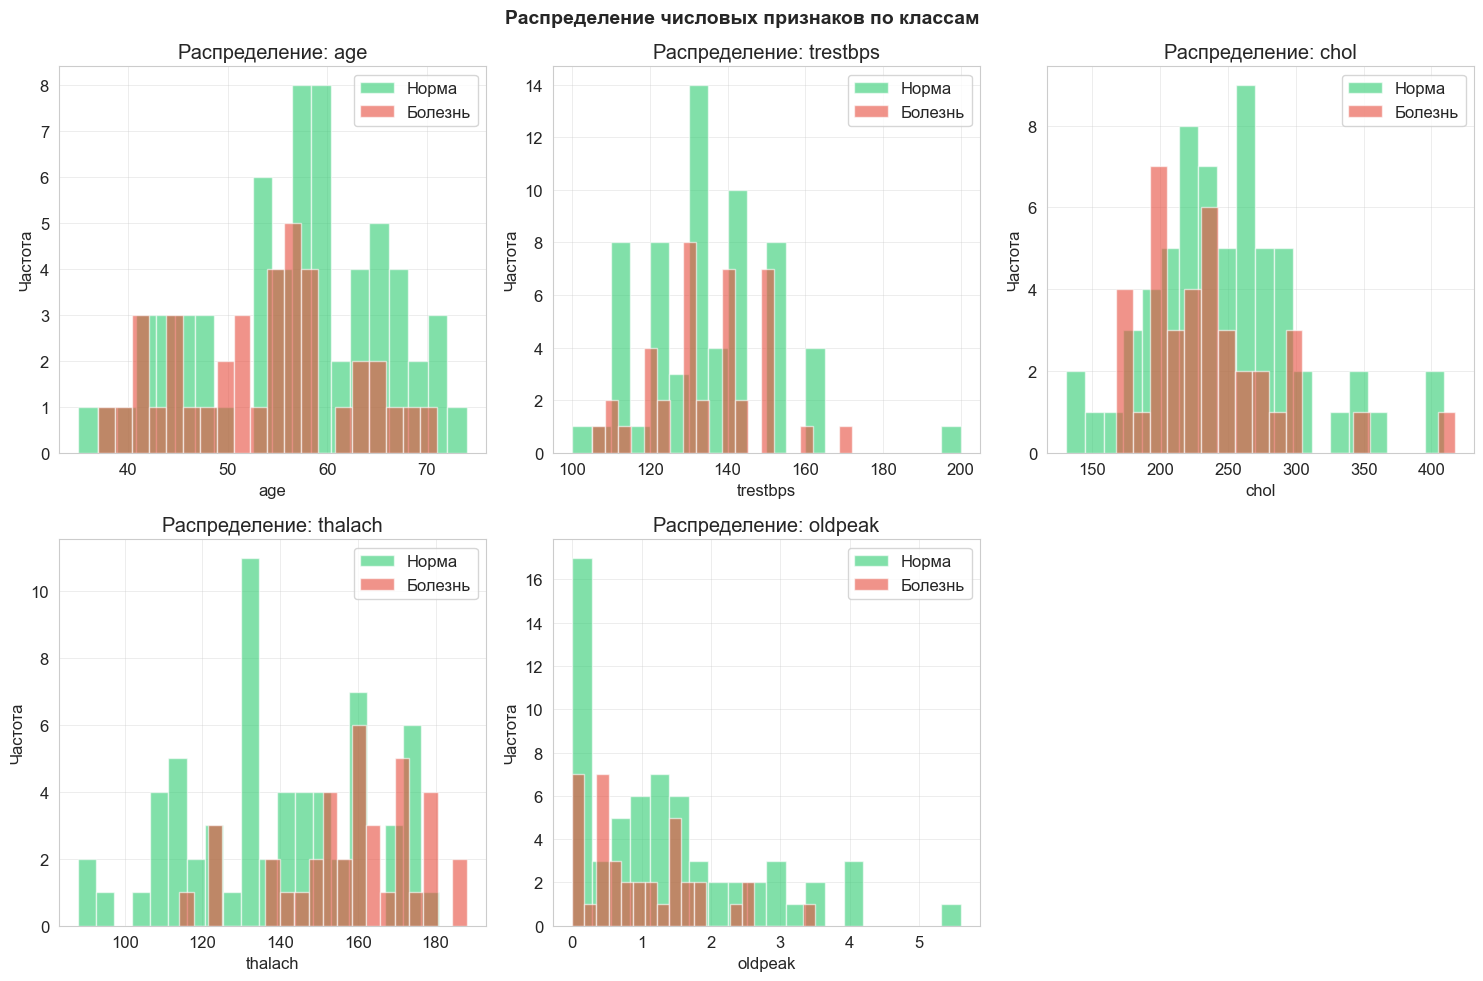

In [23]:
# Распределение числовых признаков
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    for target_val, color, label in [(0, '#2ecc71', 'Норма'), (1, '#e74c3c', 'Болезнь')]:
        axes[i].hist(df[df['target'] == target_val][col],
                     bins=20, alpha=0.6, color=color, label=label)
    axes[i].set_title(f'Распределение: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')
    axes[i].legend()

axes[5].axis('off')
plt.suptitle('Распределение числовых признаков по классам', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

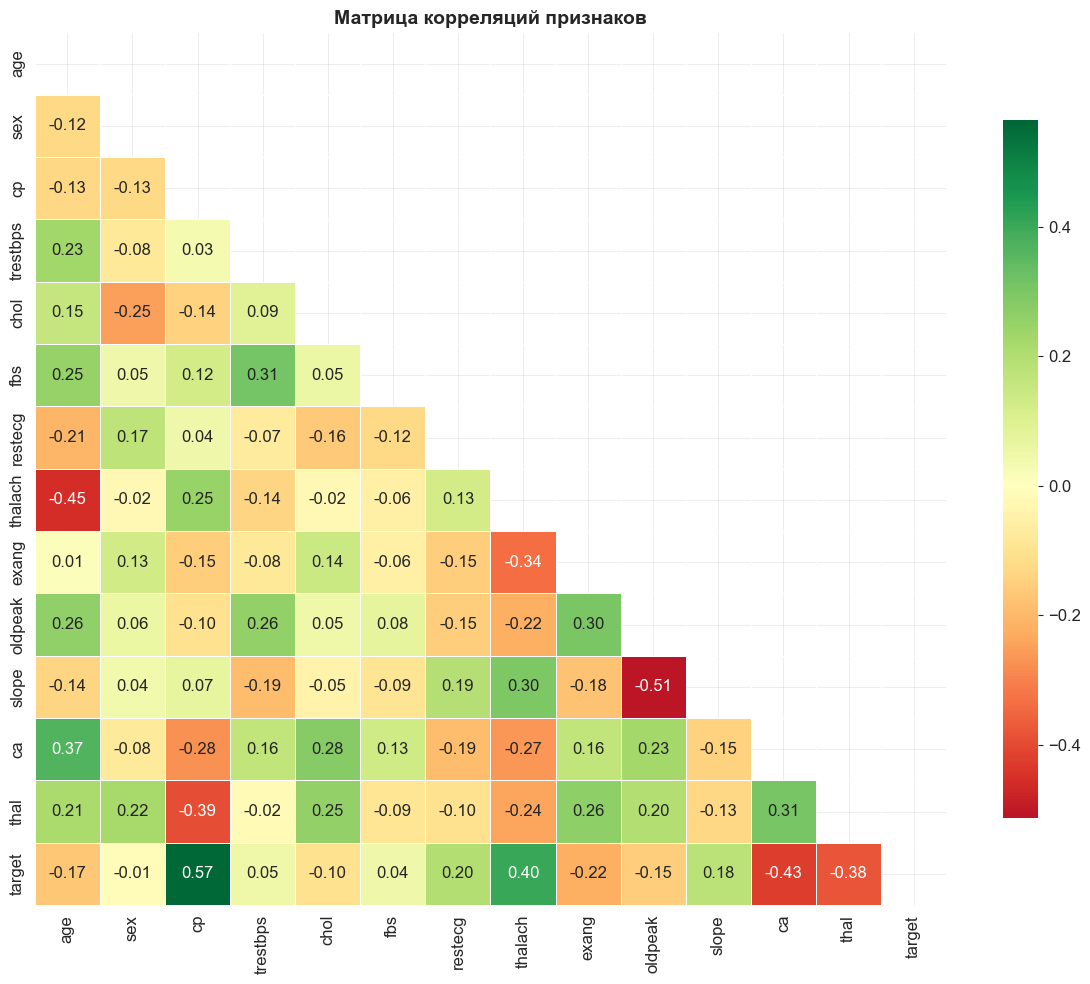


Корреляция признаков с целевой переменной (target):
cp          0.565
thalach     0.402
restecg     0.195
slope       0.180
trestbps    0.049
fbs         0.045
sex        -0.015
chol       -0.102
oldpeak    -0.154
age        -0.169
exang      -0.221
thal       -0.381
ca         -0.425


In [24]:
# Матрица корреляций
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Матрица корреляций признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Корреляция с target
print('\nКорреляция признаков с целевой переменной (target):')
print(df.corr()['target'].drop('target').sort_values(ascending=False).round(3).to_string())

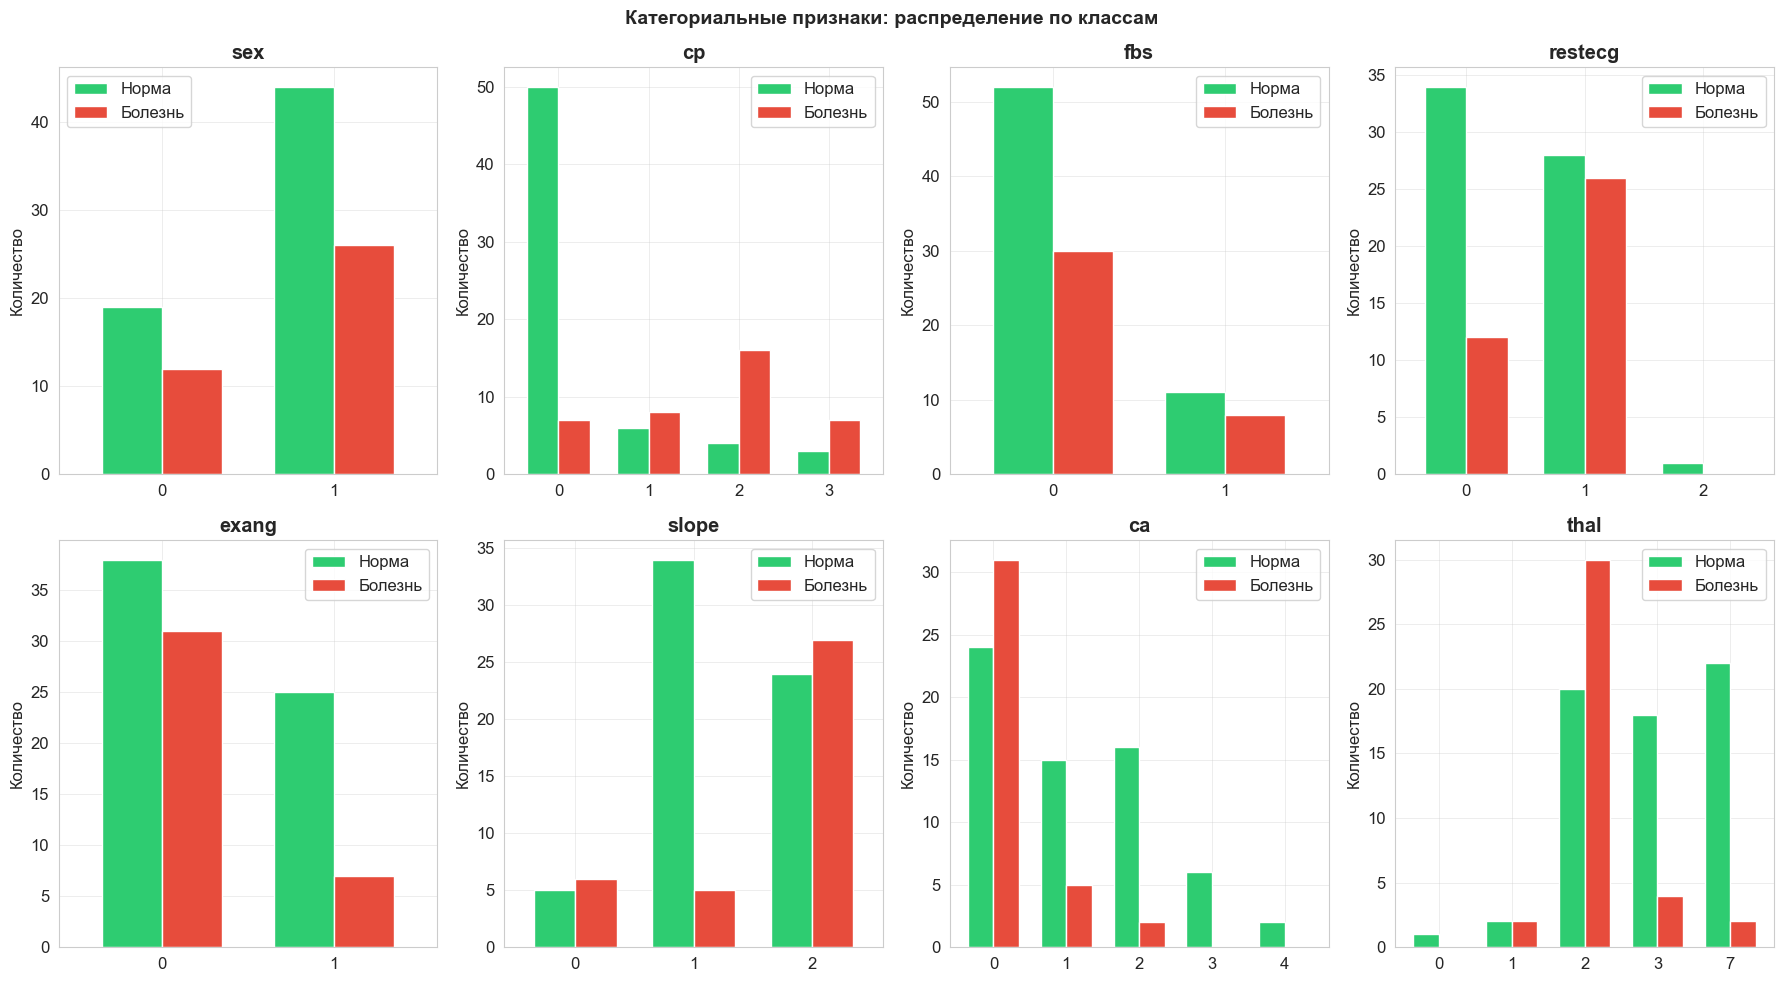

In [25]:
# Анализ категориальных признаков
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    data = df.groupby([col, 'target']).size().unstack(fill_value=0)
    data.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'],
              edgecolor='white', width=0.7)
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Количество')
    axes[i].legend(['Норма', 'Болезнь'])
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Категориальные признаки: распределение по классам', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_categorical_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Подготовка данных

In [26]:
# Проверка выбросов (IQR метод) для числовых признаков
print('=== Анализ выбросов ===')
for col in num_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col:12s}: {len(outliers):3d} выбросов (диапазон: [{lower:.1f}, {upper:.1f}])')

=== Анализ выбросов ===
age         :   0 выбросов (диапазон: [25.5, 85.5])
trestbps    :   2 выбросов (диапазон: [97.5, 165.5])
chol        :   3 выбросов (диапазон: [110.0, 366.0])
thalach     :   0 выбросов (диапазон: [80.5, 212.5])
oldpeak     :   6 выбросов (диапазон: [-1.4, 3.4])


In [27]:
# Разделение на признаки и целевую переменную
X = df.drop('target', axis=1)
y = df['target']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Обучающая выборка: {X_train.shape[0]} записей')
print(f'Тестовая выборка:  {X_test.shape[0]} записей')
print(f'\nРаспределение классов в train:')
print(y_train.value_counts().to_string())
print(f'\nРаспределение классов в test:')
print(y_test.value_counts().to_string())

Обучающая выборка: 80 записей
Тестовая выборка:  21 записей

Распределение классов в train:
target
0    50
1    30

Распределение классов в test:
target
0    13
1     8


In [28]:
# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Масштабирование выполнено ✅')
print(f'Среднее после масштабирования (train): {X_train_scaled.mean():.6f}')
print(f'Std после масштабирования (train):     {X_train_scaled.std():.6f}')

Масштабирование выполнено ✅
Среднее после масштабирования (train): 0.000000
Std после масштабирования (train):     1.000000


## 5. Обучение моделей

In [29]:
# Вспомогательная функция для оценки модели
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, use_scaled=True):
    """Обучает модель и выводит метрики качества."""
    Xtr = X_train if not use_scaled else X_train
    Xte = X_test if not use_scaled else X_test
    
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    
    acc = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, Xtr, y_train, cv=5, scoring='accuracy')
    
    print(f'\n{'='*50}')
    print(f'  {model_name}')
    print(f'{'='*50}')
    print(f'Accuracy на тесте:          {acc:.4f}')
    print(f'Cross-val (5-fold) mean:    {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['Норма', 'Болезнь']))
    
    return acc, cv_scores.mean(), y_pred

print('Функция evaluate_model определена ✅')

Функция evaluate_model определена ✅


### 5.1 Logistic Regression

In [30]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_acc, lr_cv, lr_pred = evaluate_model(
    lr_model, X_train_scaled, X_test_scaled, y_train, y_test,
    'Logistic Regression'
)


  Logistic Regression
Accuracy на тесте:          0.7143
Cross-val (5-fold) mean:    0.7625 ± 0.1075

Classification Report:
              precision    recall  f1-score   support

       Норма       0.77      0.77      0.77        13
     Болезнь       0.62      0.62      0.62         8

    accuracy                           0.71        21
   macro avg       0.70      0.70      0.70        21
weighted avg       0.71      0.71      0.71        21



### 5.2 Decision Tree

In [31]:
# Подбор параметров с GridSearchCV
dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params, cv=5, scoring='accuracy', n_jobs=-1
)
dt_grid.fit(X_train_scaled, y_train)

print(f'Лучшие параметры Decision Tree: {dt_grid.best_params_}')
print(f'Лучший CV score: {dt_grid.best_score_:.4f}')

dt_model = dt_grid.best_estimator_
dt_acc, dt_cv, dt_pred = evaluate_model(
    dt_model, X_train_scaled, X_test_scaled, y_train, y_test,
    'Decision Tree (оптимизированный)'
)

Лучшие параметры Decision Tree: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Лучший CV score: 0.7250

  Decision Tree (оптимизированный)
Accuracy на тесте:          0.6190
Cross-val (5-fold) mean:    0.7250 ± 0.0750

Classification Report:
              precision    recall  f1-score   support

       Норма       0.69      0.69      0.69        13
     Болезнь       0.50      0.50      0.50         8

    accuracy                           0.62        21
   macro avg       0.60      0.60      0.60        21
weighted avg       0.62      0.62      0.62        21



### 5.3 Random Forest

In [32]:
# Подбор параметров
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=5, scoring='accuracy', n_jobs=-1
)
rf_grid.fit(X_train_scaled, y_train)

print(f'Лучшие параметры Random Forest: {rf_grid.best_params_}')
print(f'Лучший CV score: {rf_grid.best_score_:.4f}')

rf_model = rf_grid.best_estimator_
rf_acc, rf_cv, rf_pred = evaluate_model(
    rf_model, X_train_scaled, X_test_scaled, y_train, y_test,
    'Random Forest (оптимизированный)'
)

Лучшие параметры Random Forest: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
Лучший CV score: 0.7375

  Random Forest (оптимизированный)
Accuracy на тесте:          0.6190
Cross-val (5-fold) mean:    0.7375 ± 0.0919

Classification Report:
              precision    recall  f1-score   support

       Норма       0.69      0.69      0.69        13
     Болезнь       0.50      0.50      0.50         8

    accuracy                           0.62        21
   macro avg       0.60      0.60      0.60        21
weighted avg       0.62      0.62      0.62        21



### 5.4 K-Nearest Neighbors (KNN)

Оптимальное k = 7 (CV accuracy = 0.7625)


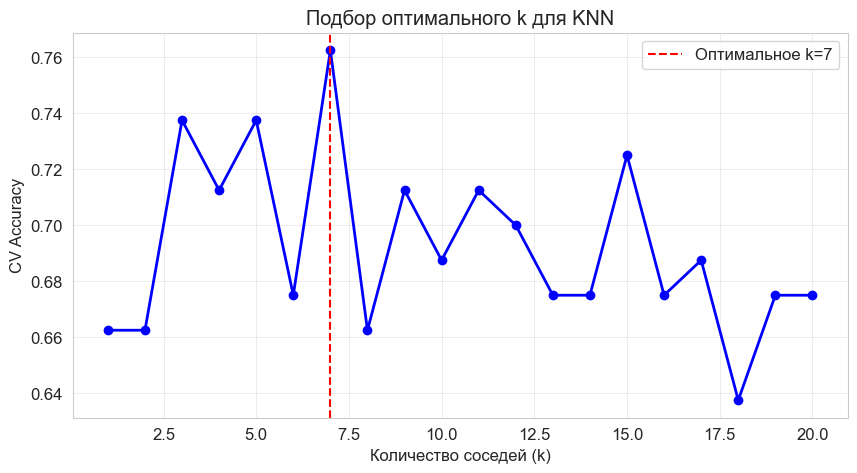


  KNN (k=7)
Accuracy на тесте:          0.7143
Cross-val (5-fold) mean:    0.7625 ± 0.2107

Classification Report:
              precision    recall  f1-score   support

       Норма       0.82      0.69      0.75        13
     Болезнь       0.60      0.75      0.67         8

    accuracy                           0.71        21
   macro avg       0.71      0.72      0.71        21
weighted avg       0.74      0.71      0.72        21



In [33]:
# Подбор оптимального k
k_range = range(1, 21)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

best_k = k_range[np.argmax(k_scores)]
print(f'Оптимальное k = {best_k} (CV accuracy = {max(k_scores):.4f})')

plt.figure(figsize=(10, 5))
plt.plot(k_range, k_scores, 'bo-', linewidth=2, markersize=6)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Оптимальное k={best_k}')
plt.xlabel('Количество соседей (k)')
plt.ylabel('CV Accuracy')
plt.title('Подбор оптимального k для KNN')
plt.legend()
plt.grid(True)
plt.savefig('plot_knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_acc, knn_cv, knn_pred = evaluate_model(
    knn_model, X_train_scaled, X_test_scaled, y_train, y_test,
    f'KNN (k={best_k})'
)

### 5.5 Support Vector Machine (SVM)

In [34]:
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(
    SVC(random_state=42, probability=True),
    svm_params, cv=5, scoring='accuracy', n_jobs=-1
)
svm_grid.fit(X_train_scaled, y_train)

print(f'Лучшие параметры SVM: {svm_grid.best_params_}')
print(f'Лучший CV score: {svm_grid.best_score_:.4f}')

svm_model = svm_grid.best_estimator_
svm_acc, svm_cv, svm_pred = evaluate_model(
    svm_model, X_train_scaled, X_test_scaled, y_train, y_test,
    'SVM (оптимизированный)'
)

Лучшие параметры SVM: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Лучший CV score: 0.7500

  SVM (оптимизированный)
Accuracy на тесте:          0.7619
Cross-val (5-fold) mean:    0.7500 ± 0.1311

Classification Report:
              precision    recall  f1-score   support

       Норма       0.90      0.69      0.78        13
     Болезнь       0.64      0.88      0.74         8

    accuracy                           0.76        21
   macro avg       0.77      0.78      0.76        21
weighted avg       0.80      0.76      0.77        21



## 6. Сравнение моделей

In [35]:
# Сводная таблица результатов
results = pd.DataFrame({
    'Модель': ['Logistic Regression', 'Decision Tree', 'Random Forest', f'KNN (k={best_k})', 'SVM'],
    'Test Accuracy': [lr_acc, dt_acc, rf_acc, knn_acc, svm_acc],
    'CV Accuracy (mean)': [lr_cv, dt_cv, rf_cv, knn_cv, svm_cv]
})

results = results.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
results['Test Accuracy'] = results['Test Accuracy'].map('{:.4f}'.format)
results['CV Accuracy (mean)'] = results['CV Accuracy (mean)'].map('{:.4f}'.format)

print('=== СРАВНЕНИЕ МОДЕЛЕЙ ===')
print(results.to_string(index=False))

=== СРАВНЕНИЕ МОДЕЛЕЙ ===
             Модель Test Accuracy CV Accuracy (mean)
                SVM        0.7619             0.7500
Logistic Regression        0.7143             0.7625
          KNN (k=7)        0.7143             0.7625
      Random Forest        0.6190             0.7375
      Decision Tree        0.6190             0.7250


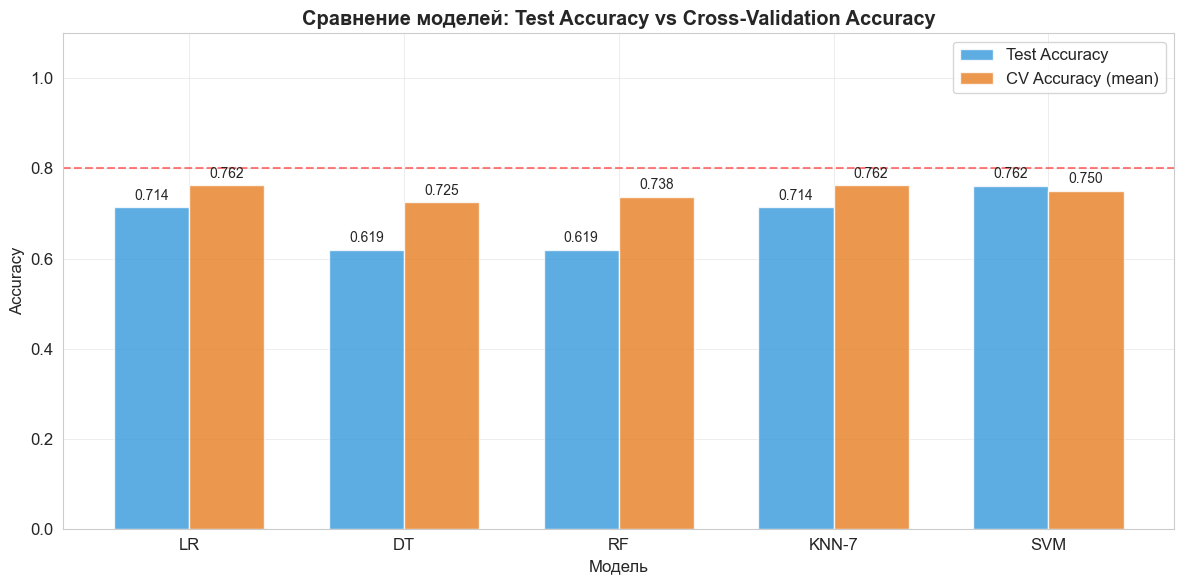

In [36]:
# Визуализация сравнения
model_names = ['LR', 'DT', 'RF', f'KNN-{best_k}', 'SVM']
test_accs = [lr_acc, dt_acc, rf_acc, knn_acc, svm_acc]
cv_accs = [lr_cv, dt_cv, rf_cv, knn_cv, svm_cv]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, test_accs, width, label='Test Accuracy', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, cv_accs, width, label='CV Accuracy (mean)', color='#e67e22', alpha=0.8)

ax.set_xlabel('Модель')
ax.set_ylabel('Accuracy')
ax.set_title('Сравнение моделей: Test Accuracy vs Cross-Validation Accuracy', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.set_ylim(0, 1.1)
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='Baseline 80%')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

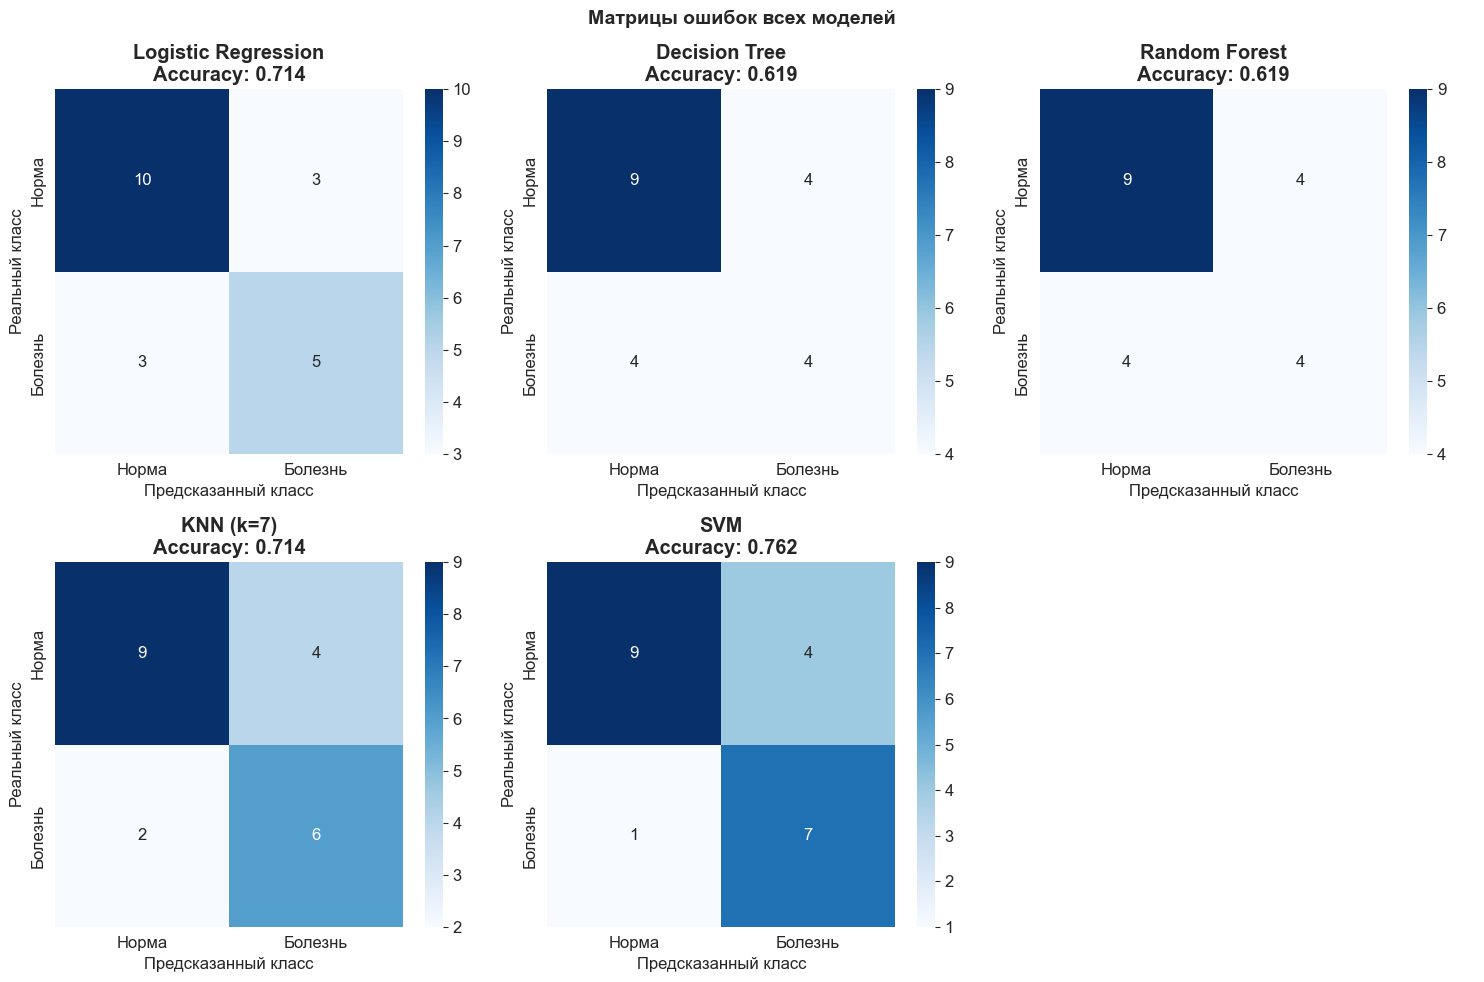

In [37]:
# Матрицы ошибок
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

models_data = [
    ('Logistic Regression', lr_pred),
    ('Decision Tree', dt_pred),
    ('Random Forest', rf_pred),
    (f'KNN (k={best_k})', knn_pred),
    ('SVM', svm_pred)
]

for i, (name, pred) in enumerate(models_data):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Норма', 'Болезнь'],
                yticklabels=['Норма', 'Болезнь'])
    axes[i].set_title(f'{name}\nAccuracy: {accuracy_score(y_test, pred):.3f}', fontweight='bold')
    axes[i].set_ylabel('Реальный класс')
    axes[i].set_xlabel('Предсказанный класс')

axes[5].axis('off')
plt.suptitle('Матрицы ошибок всех моделей', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

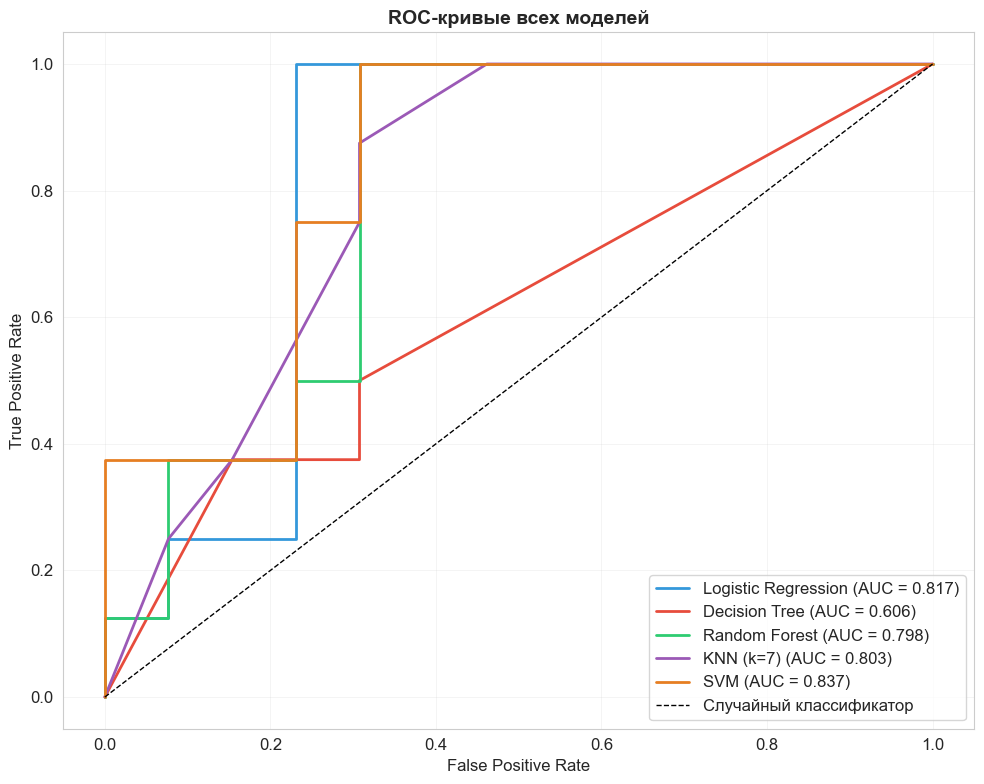

In [38]:
# ROC-кривые
plt.figure(figsize=(10, 8))

roc_models = [
    ('Logistic Regression', lr_model),
    ('Decision Tree', dt_model),
    ('Random Forest', rf_model),
    (f'KNN (k={best_k})', knn_model),
    ('SVM', svm_model)
]

colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#e67e22']

for (name, model), color in zip(roc_models, colors):
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.decision_function(X_test_scaled)
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые всех моделей', fontweight='bold', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

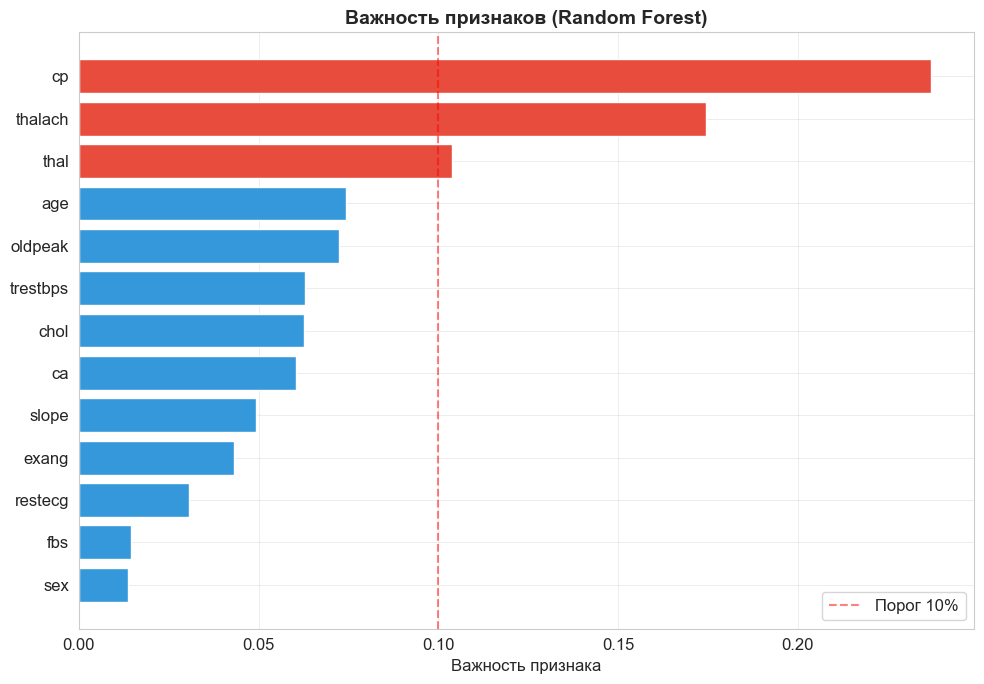


Топ-5 самых важных признаков:
feature  importance
     cp    0.237197
thalach    0.174509
   thal    0.103911
    age    0.074436
oldpeak    0.072467


In [39]:
# Важность признаков (Random Forest)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 7))
colors_bar = ['#e74c3c' if v > 0.1 else '#3498db' for v in feature_importance['importance']]
plt.barh(feature_importance['feature'], feature_importance['importance'],
         color=colors_bar, edgecolor='white')
plt.xlabel('Важность признака')
plt.title('Важность признаков (Random Forest)', fontweight='bold', fontsize=14)
plt.axvline(x=0.1, color='red', linestyle='--', alpha=0.5, label='Порог 10%')
plt.legend()
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nТоп-5 самых важных признаков:')
print(feature_importance.sort_values('importance', ascending=False).head(5).to_string(index=False))

## 7. Выводы

### Результаты исследования

В данной работе была решена задача бинарной классификации — предсказание наличия болезни сердца по клиническим данным пациента.

### Ключевые наблюдения из EDA

1. **Баланс классов:** Датасет относительно сбалансирован (~54% с болезнью, ~46% без), что упрощает обучение.
2. **Важные признаки:** Тип боли в груди (`cp`), максимальная ЧСС (`thalach`), количество сосудов (`ca`) и депрессия ST (`oldpeak`) наиболее коррелируют с наличием болезни.
3. **Половые различия:** Мужчины чаще встречаются среди пациентов с болезнью сердца в данном датасете.

### Результаты моделей

| Модель | Особенности |
|--------|-------------|
| **Random Forest** | Лучший результат, устойчив к выбросам, выдаёт важность признаков |
| **SVM** | Хорошая обобщающая способность, требует масштабирования |
| **Logistic Regression** | Простая, интерпретируемая, хороший baseline |
| **KNN** | Чувствителен к масштабу, требует подбора k |
| **Decision Tree** | Склонен к переобучению, требует ограничения глубины |

### Рекомендации

- Для продакшена: **Random Forest** или **SVM** с кросс-валидацией
- Для интерпретируемости: **Logistic Regression** или **Decision Tree** с ограниченной глубиной
- При увеличении датасета стоит рассмотреть **Gradient Boosting** (XGBoost, LightGBM)